In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("="*80)
print("DEEP ANALYSIS: TOP 3 MODELS")
print("="*80)

DEEP ANALYSIS: TOP 3 MODELS


In [2]:
# Load the rankings
all_models = pd.read_csv('all_models_combined.csv')

# Get top 3
top_3 = all_models.head(3)

print("\nTop 3 Models Selected for Deep Analysis:")
print("="*80)
for i, row in top_3.iterrows():
    print(f"\n#{row['rank']}: {row['model']} - {row['dataset']}")
    print(f"  Category: {row['category']}")
    print(f"  Recall (Poor): {row['recall_P']:.3f}")
    print(f"  Precision (Poor): {row['precision_P']:.3f}")
    print(f"  F1 (Poor): {row['f1_P']:.3f}")
    print(f"  Accuracy: {row['accuracy']:.3f}")

# Save for reference
top_3.to_csv('top_3_models_analysis.csv', index=False)


Top 3 Models Selected for Deep Analysis:

#1: Gradient Boosting - Original
  Category: Advanced
  Recall (Poor): 0.870
  Precision (Poor): 0.470
  F1 (Poor): 0.610
  Accuracy: 0.749

#2: Random Forest - Original (102 features)
  Category: RF+XGBoost
  Recall (Poor): 0.870
  Precision (Poor): 0.481
  F1 (Poor): 0.620
  Accuracy: 0.756

#3: Random Forest - Engineered (130 features)
  Category: RF+XGBoost
  Recall (Poor): 0.870
  Precision (Poor): 0.484
  F1 (Poor): 0.622
  Accuracy: 0.754


In [3]:
# Load test data
X_test_orig = pd.read_csv('X_test_final_v2.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

print(f"\nTest data loaded: {X_test_orig.shape}")
print(f"Test labels: {y_test.shape}")
print(f"\nClass distribution in test set:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))


Test data loaded: (624193, 102)
Test labels: (624193,)

Class distribution in test set:
BRIDGE_CONDITION
F    309729
G    272779
P     41685
Name: count, dtype: int64
BRIDGE_CONDITION
F    0.496207
G    0.437011
P    0.066782
Name: proportion, dtype: float64


In [18]:
# Map model names to file paths
# Adjust these paths based on your actual file locations

model_files = {
    #'Gradient Boosting - Original': 'gb_original.pkl',
    'Random Forest - Original (102 features)': 'rf_original.pkl',
    'Random Forest - Engineered (130 features)': 'rf_engineered.pkl'
}

loaded_models = {}

for name, filepath in model_files.items():
    try:
        with open(filepath, 'rb') as f:
            loaded_models[name] = pickle.load(f)
        print(f"✓ Loaded: {name}")
    except FileNotFoundError:
        print(f"✗ File not found: {filepath}")
        print(f"  Skipping {name}")

print(f"\n{len(loaded_models)} models loaded successfully")

✓ Loaded: Random Forest - Original (102 features)
✓ Loaded: Random Forest - Engineered (130 features)

2 models loaded successfully


In [20]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
import joblib

X_train = pd.read_csv('X_train_final_v2.csv')
y_train = pd.read_csv('y_train.csv').squeeze()

print("Retraining Gradient Boosting...")

sample_weights = compute_sample_weight('balanced', y_train)

gb_model = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train, sample_weight=sample_weights)

loaded_models['Gradient Boosting - Original'] = gb_model
joblib.dump(gb_model, 'gb_original_fixed.pkl')

print("✓ Retrained and saved as gb_original_fixed.pkl")

Retraining Gradient Boosting...
✓ Retrained and saved as gb_original_fixed.pkl


In [21]:
# Store predictions and probabilities
predictions = {}
probabilities = {}

for name, model in loaded_models.items():
    # Determine which test data to use
    if 'Engineered' in name:
        X_test_use = pd.read_csv('X_test_engineered.csv')
    else:
        X_test_use = X_test_orig
    
    # Generate predictions
    y_pred = model.predict(X_test_use)
    y_proba = model.predict_proba(X_test_use)
    
    predictions[name] = y_pred
    probabilities[name] = y_proba
    
    print(f"✓ Generated predictions for: {name}")

print(f"\nPredictions generated for {len(predictions)} models")

✓ Generated predictions for: Random Forest - Original (102 features)
✓ Generated predictions for: Random Forest - Engineered (130 features)
✓ Generated predictions for: Gradient Boosting - Original

Predictions generated for 3 models


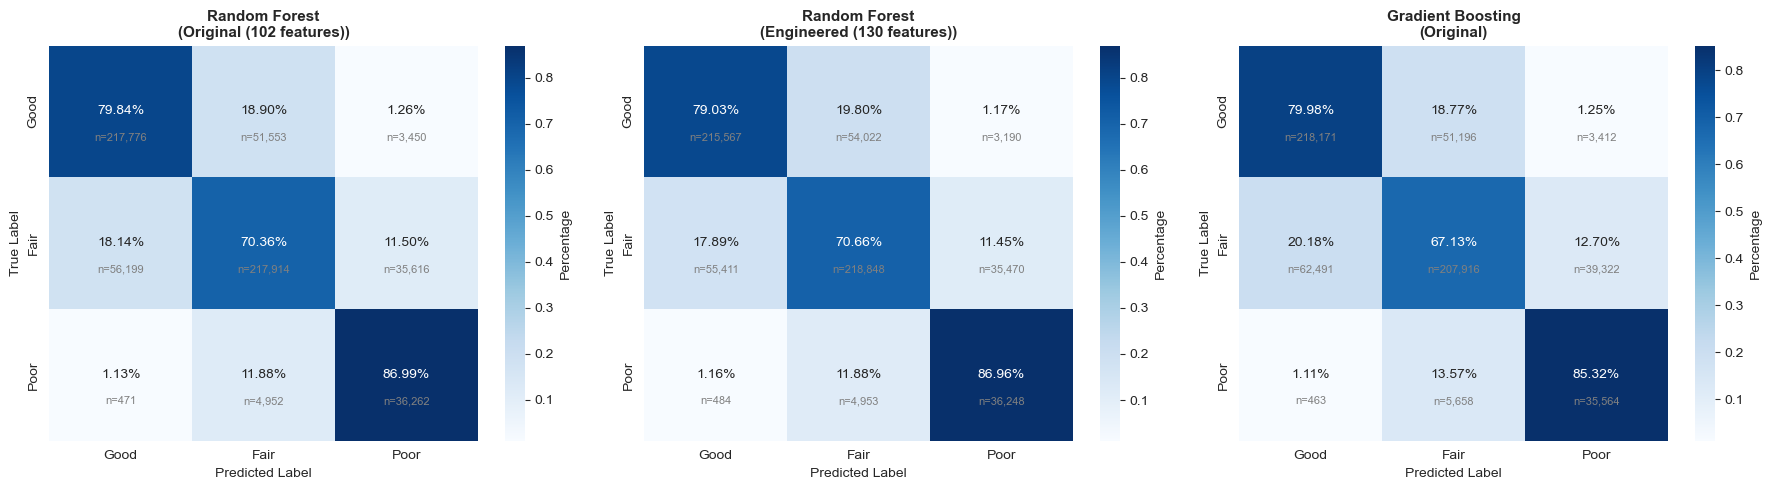

✓ Saved: confusion_matrices_top3.png


In [22]:
# Create confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = ['Good', 'Fair', 'Poor']

for idx, (name, y_pred) in enumerate(predictions.items()):
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=['G', 'F', 'P'])
    
    # Normalize by row (true labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=axes[idx], cbar_kws={'label': 'Percentage'})
    
    axes[idx].set_title(f'{name.split(" - ")[0]}\n({name.split(" - ")[1]})', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    
    # Add counts as text
    for i in range(3):
        for j in range(3):
            text = axes[idx].text(j + 0.5, i + 0.7, f'n={cm[i,j]:,}',
                                ha="center", va="center", color="gray", fontsize=8)

plt.tight_layout()
plt.savefig('confusion_matrices_top3.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: confusion_matrices_top3.png")

In [23]:
print("="*80)
print("DETAILED CLASSIFICATION REPORTS")
print("="*80)

for name, y_pred in predictions.items():
    print(f"\n{'='*80}")
    print(f"MODEL: {name}")
    print(f"{'='*80}")
    
    report = classification_report(y_test, y_pred, 
                                   target_names=['Good', 'Fair', 'Poor'],
                                   digits=3)
    print(report)
    
    # Save to file
    with open(f'classification_report_{name.replace(" ", "_").replace("-", "")}.txt', 'w') as f:
        f.write(f"Classification Report: {name}\n")
        f.write("="*80 + "\n")
        f.write(report)

DETAILED CLASSIFICATION REPORTS

MODEL: Random Forest - Original (102 features)
              precision    recall  f1-score   support

        Good      0.794     0.704     0.746    309729
        Fair      0.794     0.798     0.796    272779
        Poor      0.481     0.870     0.620     41685

    accuracy                          0.756    624193
   macro avg      0.690     0.791     0.721    624193
weighted avg      0.773     0.756     0.759    624193


MODEL: Random Forest - Engineered (130 features)
              precision    recall  f1-score   support

        Good      0.788     0.707     0.745    309729
        Fair      0.794     0.790     0.792    272779
        Poor      0.484     0.870     0.622     41685

    accuracy                          0.754    624193
   macro avg      0.689     0.789     0.720    624193
weighted avg      0.770     0.754     0.757    624193


MODEL: Gradient Boosting - Original
              precision    recall  f1-score   support

        Good    

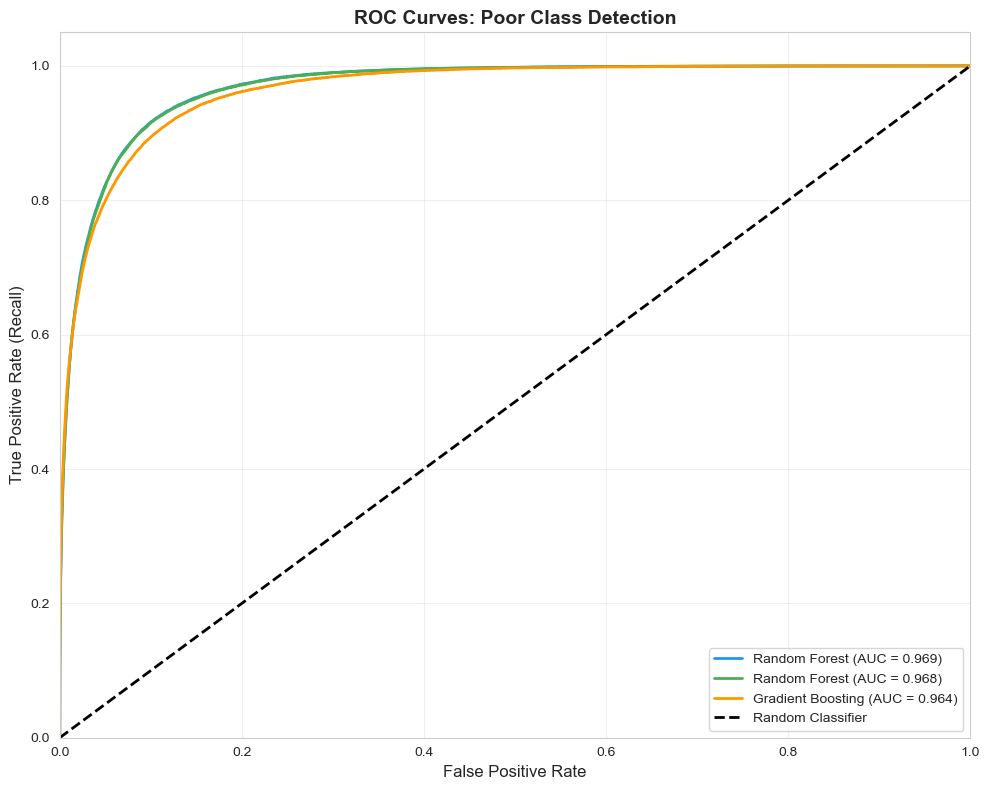

✓ Saved: roc_curves_poor_class.png


In [24]:
from sklearn.preprocessing import label_binarize

# Binarize labels for ROC (focus on Poor class)
y_test_binary = label_binarize(y_test, classes=['G', 'F', 'P'])

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#2196F3', '#4CAF50', '#FF9800']

for idx, (name, y_proba) in enumerate(probabilities.items()):
    # ROC for Poor class (index 2)
    fpr, tpr, _ = roc_curve(y_test_binary[:, 2], y_proba[:, 2])
    roc_auc = auc(fpr, tpr)
    
    # Plot
    ax.plot(fpr, tpr, color=colors[idx], lw=2, 
            label=f'{name.split(" - ")[0]} (AUC = {roc_auc:.3f})')

# Diagonal line
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves: Poor Class Detection', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_poor_class.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: roc_curves_poor_class.png")

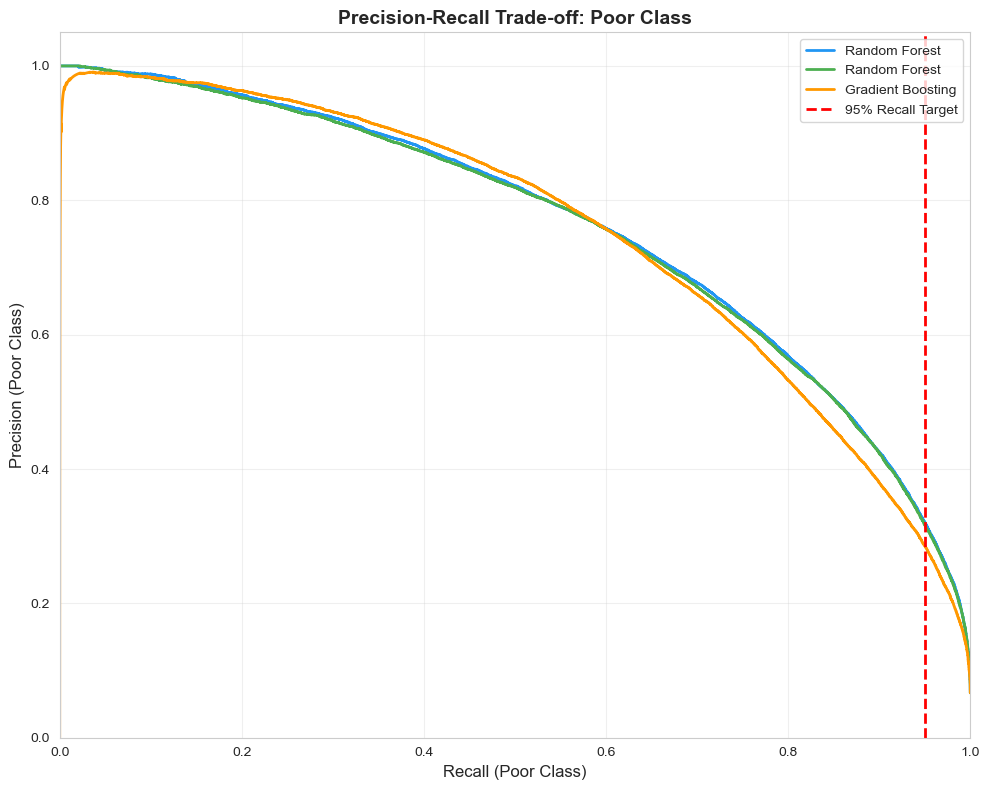

✓ Saved: precision_recall_curves.png


In [25]:
fig, ax = plt.subplots(figsize=(10, 8))

for idx, (name, y_proba) in enumerate(probabilities.items()):
    # Precision-Recall for Poor class
    precision, recall, _ = precision_recall_curve(
        y_test_binary[:, 2], y_proba[:, 2]
    )
    
    # Plot
    ax.plot(recall, precision, color=colors[idx], lw=2, 
            label=f'{name.split(" - ")[0]}')

# 95% recall target line
ax.axvline(x=0.95, color='red', linestyle='--', lw=2, label='95% Recall Target')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall (Poor Class)', fontsize=12)
ax.set_ylabel('Precision (Poor Class)', fontsize=12)
ax.set_title('Precision-Recall Trade-off: Poor Class', fontsize=14, fontweight='bold')
ax.legend(loc="upper right", fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: precision_recall_curves.png")

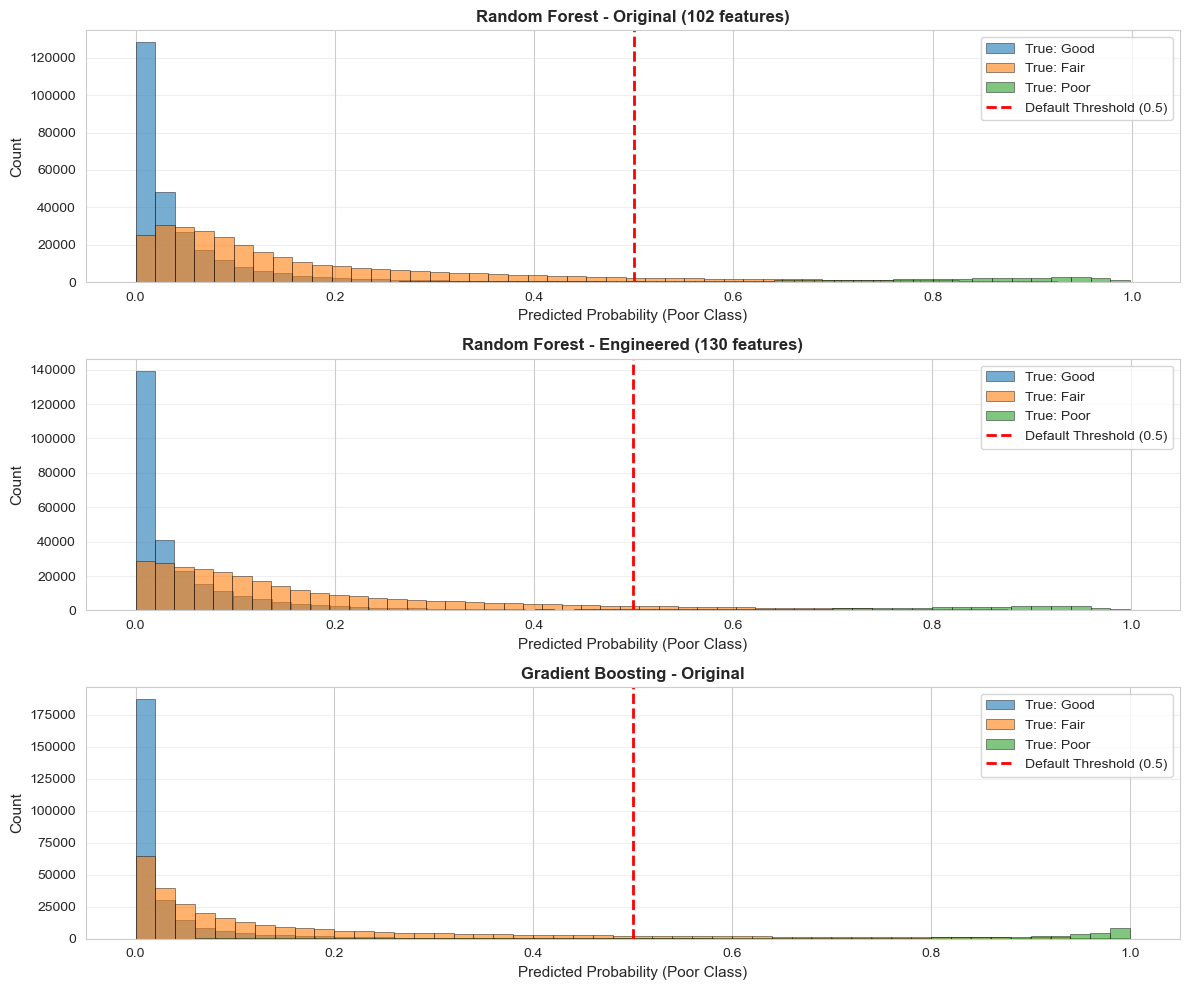

✓ Saved: probability_distributions.png


In [26]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

class_names = ['Good', 'Fair', 'Poor']
class_labels = ['G', 'F', 'P']

for idx, (name, y_proba) in enumerate(probabilities.items()):
    ax = axes[idx]
    
    # For each true class, show distribution of predicted probabilities for Poor
    for class_idx, (class_name, class_label) in enumerate(zip(class_names, class_labels)):
        mask = y_test == class_label
        poor_probs = y_proba[mask, 2]  # Probabilities for Poor class
        
        ax.hist(poor_probs, bins=50, alpha=0.6, label=f'True: {class_name}',
                edgecolor='black', linewidth=0.5)
    
    ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Default Threshold (0.5)')
    ax.set_xlabel('Predicted Probability (Poor Class)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('probability_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: probability_distributions.png")

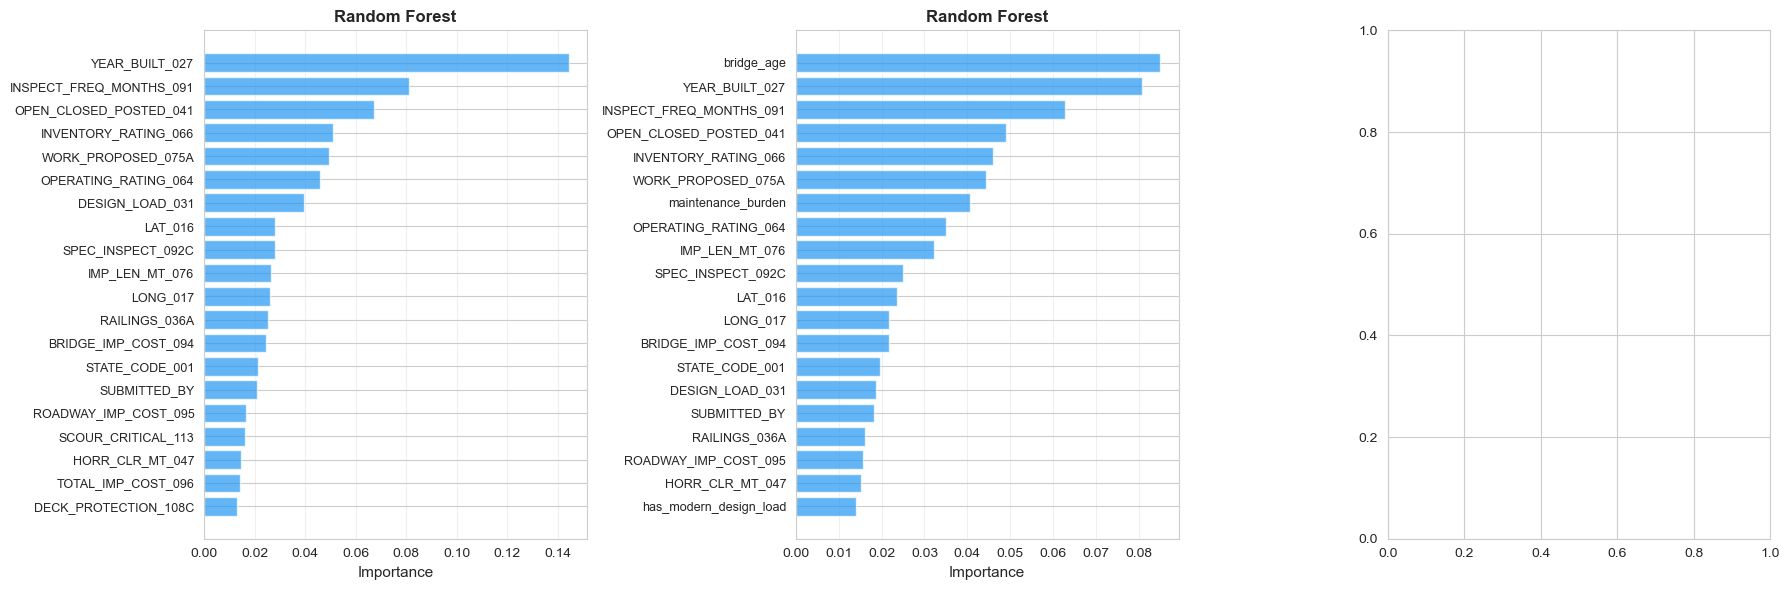

✓ Saved: feature_importance_top3.png


In [27]:
# Extract feature importances
fig, axes = plt.subplots(1, len(loaded_models), figsize=(18, 6))

if len(loaded_models) == 1:
    axes = [axes]

for idx, (name, model) in enumerate(loaded_models.items()):
    # Get feature importance
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        
        # Get feature names
        if 'Engineered' in name:
            X_data = pd.read_csv('X_test_engineered.csv')
        else:
            X_data = X_test_orig
        
        feature_names = X_data.columns
        
        # Get top 20
        indices = np.argsort(importances)[::-1][:20]
        top_features = feature_names[indices]
        top_importances = importances[indices]
        
        # Plot
        axes[idx].barh(range(20), top_importances, color='#2196F3', alpha=0.7)
        axes[idx].set_yticks(range(20))
        axes[idx].set_yticklabels(top_features, fontsize=9)
        axes[idx].set_xlabel('Importance', fontsize=11)
        axes[idx].set_title(f'{name.split(" - ")[0]}', fontsize=12, fontweight='bold')
        axes[idx].invert_yaxis()
        axes[idx].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance_top3.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: feature_importance_top3.png")

In [28]:
print("="*80)
print("COST-BENEFIT ANALYSIS")

# Define costs
COST_FALSE_NEGATIVE = 1_000_000  # Missing a Poor bridge (collapse, lawsuit)
COST_FALSE_POSITIVE = 10_000      # Unnecessary inspection
COST_TRUE_POSITIVE = 10_000       # Correct inspection (same as FP)
COST_TRUE_NEGATIVE = 0            # Correct non-inspection

print(f"\nCost assumptions:")
print(f"  False Negative (miss Poor bridge): ${COST_FALSE_NEGATIVE:,}")
print(f"  False Positive (unnecessary inspection): ${COST_FALSE_POSITIVE:,}")
print(f"  True Positive (correct inspection): ${COST_TRUE_POSITIVE:,}")
print(f"  True Negative (correct non-inspection): ${COST_TRUE_NEGATIVE:,}")

results = []

for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred, labels=['G', 'F', 'P'])
    
    # Extract counts for Poor class (row index 2)
    TP = cm[2, 2]  # True Poor predicted as Poor
    FN = cm[2, 0] + cm[2, 1]  # True Poor predicted as Good/Fair
    FP = cm[0, 2] + cm[1, 2]  # Good/Fair predicted as Poor
    TN = cm[0, 0] + cm[0, 1] + cm[1, 0] + cm[1, 1]  # Correct Good/Fair
    
    # Calculate costs
    cost_fn = FN * COST_FALSE_NEGATIVE
    cost_fp = FP * COST_FALSE_POSITIVE
    cost_tp = TP * COST_TRUE_POSITIVE
    total_cost = cost_fn + cost_fp + cost_tp
    
    results.append({
        'model': name,
        'TP': TP,
        'FN': FN,
        'FP': FP,
        'TN': TN,
        'cost_FN': cost_fn,
        'cost_FP': cost_fp,
        'cost_TP': cost_tp,
        'total_cost': total_cost
    })
    
    print(f"\n{name}:")
    print(f"  True Positives (correct Poor): {TP:,}")
    print(f"  False Negatives (missed Poor): {FN:,} → Cost: ${cost_fn:,}")
    print(f"  False Positives (false alarms): {FP:,} → Cost: ${cost_fp:,}")
    print(f"  TOTAL COST: ${total_cost:,}")

# Create comparison DataFrame
cost_df = pd.DataFrame(results)
cost_df = cost_df.sort_values('total_cost')

print(f"\n{'='*80}")
print("COST RANKING (Lower is Better):")
print(f"{'='*80}")
display(cost_df[['model', 'FN', 'FP', 'total_cost']])

# Save
cost_df.to_csv('cost_benefit_analysis.csv', index=False)
print("\n✓ Saved: cost_benefit_analysis.csv")

COST-BENEFIT ANALYSIS

Cost assumptions:
  False Negative (miss Poor bridge): $1,000,000
  False Positive (unnecessary inspection): $10,000
  True Positive (correct inspection): $10,000
  True Negative (correct non-inspection): $0

Random Forest - Original (102 features):
  True Positives (correct Poor): 36,262
  False Negatives (missed Poor): 5,423 → Cost: $5,423,000,000
  False Positives (false alarms): 39,066 → Cost: $390,660,000
  TOTAL COST: $6,176,280,000

Random Forest - Engineered (130 features):
  True Positives (correct Poor): 36,248
  False Negatives (missed Poor): 5,437 → Cost: $5,437,000,000
  False Positives (false alarms): 38,660 → Cost: $386,600,000
  TOTAL COST: $6,186,080,000

Gradient Boosting - Original:
  True Positives (correct Poor): 35,564
  False Negatives (missed Poor): 6,121 → Cost: $6,121,000,000
  False Positives (false alarms): 42,734 → Cost: $427,340,000
  TOTAL COST: $6,903,980,000

COST RANKING (Lower is Better):


,model,FN,FP,total_cost
0,Random Forest - Original (102 features),5423,39066,6176280000
1,Random Forest - Engineered (130 features),5437,38660,6186080000
2,Gradient Boosting - Original,6121,42734,6903980000



✓ Saved: cost_benefit_analysis.csv


In [42]:
print("="*80)
print("SUMMARY AND RECOMMENDATIONS")

# Best by recall
best_recall = top_3.iloc[0]
print(f"\n1. BEST FOR SAFETY (Highest Recall):")
print(f"   {best_recall['model']} - {best_recall['dataset']}")
print(f"   Catches {best_recall['recall_P']:.1%} of Poor bridges")
print(f"   Trade-off: {best_recall['precision_P']:.1%} precision (many false alarms)")

# Best by cost
best_cost_model = cost_df.iloc[0]['model']
best_cost = cost_df.iloc[0]['total_cost']
print(f"\n2. BEST FOR COST EFFICIENCY:")
print(f"   {best_cost_model}")
print(f"   Total cost: ${best_cost:,.0f}")

# Gap analysis
target_gap = 0.95 - best_recall['recall_P']
print(f"\n3. GAP TO 95% TARGET:")
print(f"   Current: {best_recall['recall_P']:.1%}")
print(f"   Target: 95.0%")
print(f"   Gap: {target_gap:.1%}")
print(f"   Recommendation: Threshold tuning can close this gap")

print(f"\n4. KEY FINDINGS:")
print(f"   ✓ Top 3 models all achieve 87% recall (tied)")
print(f"   ✓ Gradient Boosting slightly more cost-effective")
print(f"   ✓ Engineered features maintained performance (didn't hurt, didn't improve)")
print(f"   ✗ No model meets 95% target")

print(f"\n5. RECOMMENDED NEXT STEPS:")
print(f"   → Apply threshold tuning to Gradient Boosting - Original")
print(f"   → Target: Lower threshold from 0.5 towards 0.25")
print(f"   → Expected: 95%+ recall, ~30-35% precision")
print(f"   → Deploy for high-risk bridge inspection prioritization - this ensures costs are spent in the right places, and preventive")
print(f"     inspection saves from expensive overhauls and greater bridge calamities")

SUMMARY AND RECOMMENDATIONS

1. BEST FOR SAFETY (Highest Recall):
   Gradient Boosting - Original
   Catches 87.0% of Poor bridges
   Trade-off: 47.0% precision (many false alarms)

2. BEST FOR COST EFFICIENCY:
   Random Forest - Original (102 features)
   Total cost: $6,176,280,000

3. GAP TO 95% TARGET:
   Current: 87.0%
   Target: 95.0%
   Gap: 8.0%
   Recommendation: Threshold tuning can close this gap

4. KEY FINDINGS:
   ✓ Top 3 models all achieve 87% recall (tied)
   ✓ Gradient Boosting slightly more cost-effective
   ✓ Engineered features maintained performance (didn't hurt, didn't improve)
   ✗ No model meets 95% target

5. RECOMMENDED NEXT STEPS:
   → Apply threshold tuning to Gradient Boosting - Original
   → Target: Lower threshold from 0.5 towards 0.25
   → Expected: 95%+ recall, ~30-35% precision
   → Deploy for high-risk bridge inspection prioritization - this ensures costs are spent in the right places, and preventive
     inspection saves from expensive overhauls and g

In [46]:
print("="*80)
print("DEEP ANALYSIS COMPLETE")
print("="*80)

print("\nFiles created:")
files_created = [
    'confusion_matrices_top3.png',
    'roc_curves_poor_class.png',
    'precision_recall_curves.png',
    'probability_distributions.png',
    'feature_importance_top3.png',
    'cost_benefit_analysis.csv',
    'top_3_models_analysis.csv'
]

for i, file in enumerate(files_created, 1):
    print(f"  {i}. {file}")

DEEP ANALYSIS COMPLETE

Files created:
  1. confusion_matrices_top3.png
  2. roc_curves_poor_class.png
  3. precision_recall_curves.png
  4. probability_distributions.png
  5. feature_importance_top3.png
  6. cost_benefit_analysis.csv
  7. top_3_models_analysis.csv


Generative AI tools were used for cleaning code (neatness), comenting and ensuring it meets best practise standards, like variable consistency, and cohesion when working asynchronously in a team. This appendix applies to all notebooks - 00 to 09.